# Quantum mechanics of spin and magnetism

## From one spin to spinful Bloch states

This notebook develops two executable models:

1. **A single spin-$\tfrac12$ in a magnetic field:** state vectors, Pauli operators, measurement, Zeeman splitting, and Larmor precession.
2. **Spinful Bloch states on a periodic lattice:** translation symmetry, band formation, exchange splitting, spin-orbit coupling, and band spin polarization.

The first model isolates the internal two-level degree of freedom. The second attaches that spin space to every unit cell of a periodic lattice.

## Learning objectives

After completing the notebook, you should be able to:

- represent a spin-$\tfrac12$ state in $\mathbb C^2$;
- construct spin operators from the Pauli matrices;
- compute expectation values, projective-measurement probabilities, and Zeeman eigenstates;
- propagate a state under a time-independent Hamiltonian;
- interpret Larmor precession as unitary rotation of the spin expectation value;
- construct a finite periodic tight-binding Hamiltonian with a spin degree of freedom;
- reduce the real-space Hamiltonian into $k$-resolved Bloch Hamiltonians;
- distinguish lattice Bloch phase from the internal spinor;
- calculate band energies and momentum-resolved spin expectation values;
- distinguish input exchange splitting, spin polarization, and physical magnetization.

## Two uses of “Bloch”

The word **Bloch** appears in two places in this notebook, but it refers to two mathematically different constructions. The distinction is important because both constructions eventually occur in the same spinful lattice state. The **Bloch sphere** describes the internal state of a two-level system. A **Bloch state** describes how a quantum state transforms under translation through a periodic lattice.

| Object | Meaning | State space |
| --- | --- | --- |
| Bloch vector or Bloch sphere | Representation of a pure two-level state by $\mathbf r=\langle\boldsymbol\sigma\rangle$ | $\mathbb C^2$ |
| Bloch state | Translation eigenstate in a periodic lattice | $\mathbb C^N\otimes\mathbb C^2$ before $k$ reduction |

### The Bloch vector of a spin state

A spin-$\tfrac12$ state is a normalized vector $|\psi\rangle\in\mathbb C^2$. The vector contains two complex amplitudes, but normalization removes one real degree of freedom and the physically irrelevant global phase removes another. A pure spin state therefore has two independent real parameters. These parameters may be represented as a point on the unit sphere through

$$
\mathbf r
=
\langle\psi|\boldsymbol\sigma|\psi\rangle,
$$

where $\boldsymbol\sigma=(\sigma_x,\sigma_y,\sigma_z)$. Equivalently, the state projector is

$$
|\psi\rangle\langle\psi|
=
\frac12\left(I+\mathbf r\cdot\boldsymbol\sigma\right).
$$

For a pure state, $|\mathbf r|=1$. Mixed states lie inside the sphere and satisfy $|\mathbf r|<1$. The Bloch vector contains the expectation values of the three Pauli operators and therefore determines the probabilities of spin measurements along any direction. It does **not** describe the position of the particle, the periodicity of a crystal, or the crystal momentum $k$. It is a representation of the internal two-level state.

### The Bloch state of a periodic lattice

A lattice Bloch state follows from a different structure: discrete translation symmetry. Consider $N$ periodically repeated cells, with one orbital and two spin states in each cell. Before using translation symmetry, the state space is

$$
\mathcal H
=
\mathcal H_{\mathrm{site}}\otimes\mathcal H_{\mathrm{spin}}
=
\mathbb C^N\otimes\mathbb C^2.
$$

The first factor records the cell amplitudes. The second factor records the spin amplitudes. Translation through one lattice spacing acts on the cell index and leaves the spin index unchanged in the present model:

$$
T_a
=
T_a^{(\mathrm{site})}\otimes I_2.
$$

If the Hamiltonian is periodic, then $[H,T_a]=0$. The Hamiltonian and translation operator can then be resolved into common crystal-momentum sectors. A spinful Bloch state has the form

$$
|\Psi_{nk}\rangle
=
\frac{1}{\sqrt N}
\sum_{j=0}^{N-1}
e^{ikR_j}
|j\rangle\otimes|u_n(k)\rangle,
$$

where $e^{ikR_j}$ is the lattice phase and $|u_n(k)\rangle$ is the internal state within one unit cell. The band label $n$ distinguishes different eigenvectors of the Hamiltonian at the same $k$. In the minimal one-orbital model used here, $|u_n(k)\rangle\in\mathbb C^2$ is a spinor. In a multi-orbital model, it would contain both orbital and spin components.

### How the two constructions meet

The internal spinor of each lattice Bloch state has its own Bloch vector,

$$
\mathbf r_n(k)
=
\langle u_n(k)|\boldsymbol\sigma|u_n(k)\rangle.
$$

This quantity is the spin expectation value of band $n$ at crystal momentum $k$. If $\mathbf r_n(k)$ changes across the Brillouin zone, the band has a momentum-dependent **spin texture**. Thus the two meanings of Bloch meet only after their roles have been separated:

- $e^{ikR_j}$ describes how the state transforms from one unit cell to the next;
- $|u_n(k)\rangle$ describes the internal state within a unit cell;
- $\mathbf r_n(k)$ describes the spin carried by that internal state.

The lattice Fourier transform produces the exact finite-dimensional decomposition

$$
\underbrace{\mathbb C^N\otimes\mathbb C^2}_{\text{finite real-space ring}}
\cong
\bigoplus_{k}
\underbrace{\mathbb C^2}_{\text{spin fiber at fixed }k}.
$$

The dimensions agree: the real-space model has $2N$ basis states, while the momentum-space representation has $N$ allowed $k$ values and two internal spin states for each $k$. This is a change of basis, not a model approximation. It becomes block diagonal because the periodic Hamiltonian preserves each $k$ sector. Open boundaries, disorder, or any perturbation that breaks translation symmetry destroys this exact decomposition, although momentum-space descriptions may remain approximately useful.

### Numerical conventions

We use $\hbar=1$ and lattice spacing $a=1$ in the code. Crystal momentum is therefore plotted through the dimensionless combination $ka$. The hopping amplitude $\tau$ defines the lattice energy scale, while $\Delta$ and $\lambda$ are expressed in the same energy unit. If the energy unit is $E_0$, the corresponding time unit in the single-spin calculation is $\hbar/E_0$.

# Part I — A single spin-$\tfrac12$

## 1. State space and spin operators

Choose the $S_z$ basis

$$
|\uparrow_z\rangle=
\begin{pmatrix}1\\0\end{pmatrix},
\qquad
|\downarrow_z\rangle=
\begin{pmatrix}0\\1\end{pmatrix}.
$$

A normalized pure state is

$$
|\psi\rangle
=a|\uparrow_z\rangle+b|\downarrow_z\rangle,
\qquad
|a|^2+|b|^2=1.
$$

The Pauli matrices are

$$
\sigma_x=
\begin{pmatrix}0&1\\1&0\end{pmatrix},
\quad
\sigma_y=
\begin{pmatrix}0&-i\\i&0\end{pmatrix},
\quad
\sigma_z=
\begin{pmatrix}1&0\\0&-1\end{pmatrix},
$$

and the spin operators are $S_\alpha=\sigma_\alpha/2$ in units $\hbar=1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

I2 = np.eye(2, dtype=complex)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
pauli = np.array([sigma_x, sigma_y, sigma_z])

Sx, Sy, Sz = pauli / 2.0
up_z = np.array([1, 0], dtype=complex)
down_z = np.array([0, 1], dtype=complex)
plus_x = (up_z + down_z) / np.sqrt(2)


def commutator(A, B):
    return A @ B - B @ A


assert np.allclose(commutator(Sx, Sy), 1j * Sz)
assert np.allclose(commutator(Sy, Sz), 1j * Sx)
assert np.allclose(commutator(Sz, Sx), 1j * Sy)
assert np.allclose(Sx @ Sx + Sy @ Sy + Sz @ Sz, 3.0 / 4.0 * I2)

print("[Sx, Sy] =")
print(commutator(Sx, Sy))
print("S^2 =")
print(Sx @ Sx + Sy @ Sy + Sz @ Sz)
print("Operator-algebra checks passed.")

[Sx, Sy] =
[[0.+0.5j 0.+0.j ]
 [0.+0.j  0.-0.5j]]
S^2 =
[[0.75+0.j 0.  +0.j]
 [0.  +0.j 0.75+0.j]]
Operator-algebra checks passed.


## 2. States, projectors, and measurement

A general pure spin state can be parameterized by

$$
|\psi(\theta,\phi)\rangle
=
\cos\frac{\theta}{2}|\uparrow_z\rangle
+e^{i\phi}\sin\frac{\theta}{2}|\downarrow_z\rangle.
$$

Its Bloch vector is

$$
\mathbf r
=
\langle\psi|\boldsymbol\sigma|\psi\rangle
=
(\sin\theta\cos\phi,\sin\theta\sin\phi,\cos\theta).
$$

For a pure state, $|\mathbf r|=1$. Measurement of spin along a unit vector $\mathbf n$ uses the projectors

$$
P_\pm(\mathbf n)
=\frac12\left(I\pm\mathbf n\cdot\boldsymbol\sigma\right),
$$

with probabilities

$$
p_\pm
=\langle\psi|P_\pm|\psi\rangle
=\frac12(1\pm\mathbf r\cdot\mathbf n).
$$

In [2]:
def normalize(state):
    state = np.asarray(state, dtype=complex)
    norm = np.linalg.norm(state)
    if norm == 0:
        raise ValueError("A quantum state cannot be the zero vector.")
    return state / norm


def spinor(theta, phi):
    return np.array(
        [np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2)],
        dtype=complex,
    )


def expectation(state, operator):
    state = normalize(state)
    return np.vdot(state, operator @ state)


def bloch_vector(state):
    return np.real_if_close([expectation(state, matrix) for matrix in pauli]).astype(float)


def pauli_dot(vector):
    vector = np.asarray(vector, dtype=float)
    return sum(component * matrix for component, matrix in zip(vector, pauli))


def spin_projector(direction, sign=+1):
    direction = np.asarray(direction, dtype=float)
    direction = direction / np.linalg.norm(direction)
    if sign not in (-1, +1):
        raise ValueError("sign must be +1 or -1.")
    return 0.5 * (I2 + sign * pauli_dot(direction))


psi = spinor(theta=2 * np.pi / 3, phi=np.pi / 4)
r = bloch_vector(psi)
n_measure = np.array([1.0, 1.0, 0.0]) / np.sqrt(2)
p_plus = np.real(expectation(psi, spin_projector(n_measure, +1)))
p_minus = np.real(expectation(psi, spin_projector(n_measure, -1)))

assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(r), 1.0)
assert np.isclose(p_plus + p_minus, 1.0)

print("State |psi> =", psi)
print("Bloch vector r =", r)
print("Measurement direction n =", n_measure)
print(f"p(+) = {p_plus:.4f}, p(-) = {p_minus:.4f}")

State |psi> = [0.5   +0.j     0.6124+0.6124j]
Bloch vector r = [ 0.6124  0.6124 -0.5   ]
Measurement direction n = [0.7071 0.7071 0.    ]
p(+) = 0.9330, p(-) = 0.0670


## 3. Zeeman Hamiltonian

To avoid hiding a sign convention inside a gyromagnetic ratio, define the effective Zeeman Hamiltonian as

$$
\boxed{
H_Z=-\frac{\Delta}{2}\,\mathbf n_B\cdot\boldsymbol\sigma,
}
$$

where $\Delta>0$ is the energy splitting and $\mathbf n_B$ is the effective-field direction. The lower-energy eigenstate has spin expectation parallel to $\mathbf n_B$.

For an electron, spin angular momentum and magnetic moment point oppositely:

$$
\boldsymbol\mu_e
=-g\mu_B\frac{\mathbf S}{\hbar}.
$$

Consequently, a plot of spin polarization is not automatically a plot of electron magnetic moment or magnetization; the conversion and sign must be stated.

In [3]:
def zeeman_hamiltonian(delta, direction):
    direction = np.asarray(direction, dtype=float)
    direction = direction / np.linalg.norm(direction)
    return -0.5 * delta * pauli_dot(direction)


delta = 2.4
n_B = np.array([1.0, 2.0, 3.0])
n_B = n_B / np.linalg.norm(n_B)
H_Z = zeeman_hamiltonian(delta, n_B)
energies, eigenvectors = np.linalg.eigh(H_Z)

ground_state = eigenvectors[:, 0]
excited_state = eigenvectors[:, 1]

assert np.allclose(H_Z, H_Z.conj().T)
assert np.allclose(energies, [-delta / 2, +delta / 2])
assert np.allclose(bloch_vector(ground_state), n_B)
assert np.allclose(bloch_vector(excited_state), -n_B)

print("H_Z =")
print(H_Z)
print("Eigenenergies:", energies)
print("Ground-state Bloch vector:", bloch_vector(ground_state))
print("Excited-state Bloch vector:", bloch_vector(excited_state))

H_Z =
[[-0.9621+0.j     -0.3207+0.6414j]
 [-0.3207-0.6414j  0.9621-0.j    ]]
Eigenenergies: [-1.2  1.2]
Ground-state Bloch vector: [0.2673 0.5345 0.8018]
Excited-state Bloch vector: [-0.2673 -0.5345 -0.8018]


## 4. Unitary time evolution and Larmor precession

For a time-independent Hamiltonian,

$$
|\psi(t)\rangle
=U(t)|\psi(0)\rangle,
\qquad
U(t)=e^{-iHt}.
$$

If $H_Z=-(\Delta/2)\sigma_z$ and the initial state is $|+x\rangle$, the Bloch vector rotates about the $z$ axis with angular frequency $\Delta$ in the units used here. Norm and energy expectation remain constant because $U(t)$ is unitary.

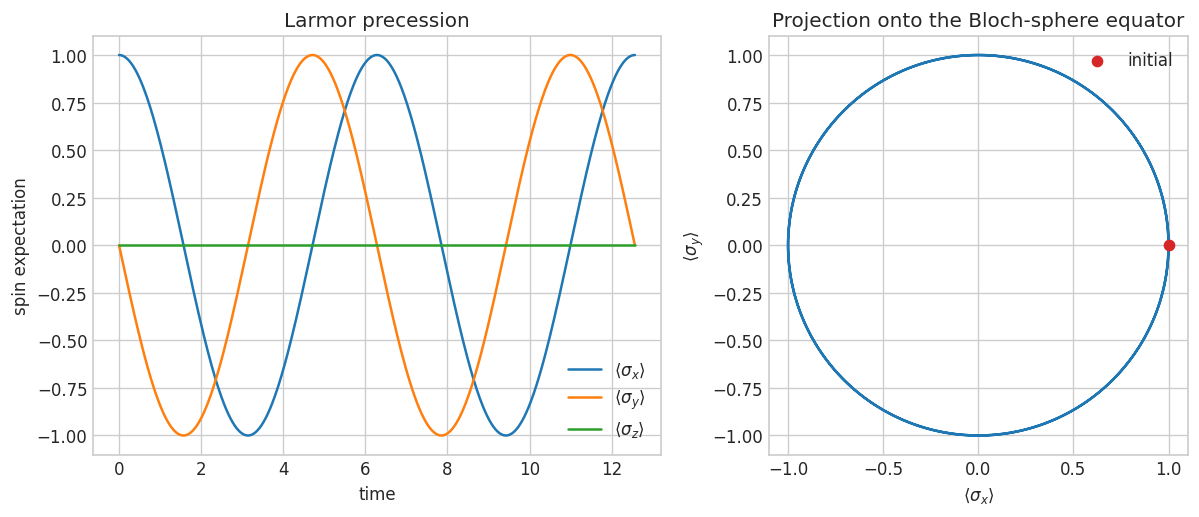

In [4]:
def evolve_time_independent(H, state_0, times):
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    coefficients = eigenvectors.conj().T @ normalize(state_0)
    phases = np.exp(-1j * np.outer(times, eigenvalues))
    return (phases * coefficients) @ eigenvectors.T


H_precession = zeeman_hamiltonian(delta=1.0, direction=[0, 0, 1])
times = np.linspace(0, 4 * np.pi, 500)
states_t = evolve_time_independent(H_precession, plus_x, times)
bloch_t = np.array([bloch_vector(state) for state in states_t])
norms_t = np.sum(np.abs(states_t) ** 2, axis=1)
energy_t = np.real(np.einsum("ti,ij,tj->t", states_t.conj(), H_precession, states_t))

assert np.allclose(norms_t, 1.0)
assert np.allclose(energy_t, energy_t[0])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
axes[0].plot(times, bloch_t[:, 0], label=r"$\langle\sigma_x\rangle$")
axes[0].plot(times, bloch_t[:, 1], label=r"$\langle\sigma_y\rangle$")
axes[0].plot(times, bloch_t[:, 2], label=r"$\langle\sigma_z\rangle$")
axes[0].set(xlabel="time", ylabel="spin expectation", title="Larmor precession")
axes[0].legend()

axes[1].plot(bloch_t[:, 0], bloch_t[:, 1])
axes[1].scatter([bloch_t[0, 0]], [bloch_t[0, 1]], color="tab:red", zorder=3, label="initial")
axes[1].set(
    xlabel=r"$\langle\sigma_x\rangle$",
    ylabel=r"$\langle\sigma_y\rangle$",
    title="Projection onto the Bloch-sphere equator",
    aspect="equal",
    xlim=(-1.1, 1.1),
    ylim=(-1.1, 1.1),
)
axes[1].legend()
plt.show()

### Checkpoint: what the simple model establishes

- The state is a vector in $\mathbb C^2$.
- Spin components are noncommuting operators.
- A magnetic coupling is a $2\times2$ Hermitian matrix.
- Measurement probabilities come from projectors.
- Dynamics is generated by the Hamiltonian, not imposed as a classical rotation.

The model does **not** yet contain spatial motion, a lattice, exchange generated by interactions, or band structure.

# Part II — Spinful Bloch states

## 5. Translation symmetry and the lattice state space

Consider a ring of $N$ unit cells with one orbital and two spin states per cell. The finite state space is

$$
\mathcal H
=\mathcal H_{\mathrm{site}}\otimes\mathcal H_{\mathrm{spin}}
=\mathbb C^N\otimes\mathbb C^2.
$$

Let $|j,s\rangle=|j\rangle\otimes|s\rangle$, where $j=0,\ldots,N-1$ and $s\in\{\uparrow_z,\downarrow_z\}$. Define translation by one cell through

$$
\hat T_a|j,s\rangle=|j+1\bmod N,s\rangle.
$$

With the convention

$$
|k\rangle
=\frac{1}{\sqrt N}\sum_{j=0}^{N-1}e^{ikja}|j\rangle,
$$

we obtain

$$
\hat T_a|k\rangle=e^{-ika}|k\rangle.
$$

The sign of the translation eigenvalue follows from this explicit convention; changing the definition of either $|k\rangle$ or $\hat T_a$ changes that sign without changing the physics.

## 6. A minimal magnetic tight-binding model

Let $\tau>0$ be a spin-independent nearest-neighbor hopping amplitude, $\Delta$ an imposed exchange or Zeeman splitting, and $\lambda$ a spin-dependent hopping strength. Define the forward hopping block

$$
K=-\tau I+i\lambda\sigma_y.
$$

The real-space Hamiltonian is

$$
H
=\sum_j\left(
|j+1\rangle\langle j|\otimes K
+|j\rangle\langle j+1|\otimes K^\dagger
\right)
-\frac{\Delta}{2}\sum_j|j\rangle\langle j|\otimes\sigma_z.
$$

Translation symmetry implies $[H,T_a]=0$. At fixed crystal momentum,

$$
\boxed{
H(k)
=-2\tau\cos(ka)I
+2\lambda\sin(ka)\sigma_y
-\frac{\Delta}{2}\sigma_z.
}
$$

Thus a $2N\times2N$ matrix becomes $N$ independent $2\times2$ matrices. The numerical reduction is a discrete Fourier transform of the cell index.

In [5]:
def translation_operator(n_cells):
    site_translation = np.zeros((n_cells, n_cells), dtype=complex)
    for j in range(n_cells):
        site_translation[(j + 1) % n_cells, j] = 1.0
    return np.kron(site_translation, I2)


def real_space_hamiltonian(n_cells, t_hop=1.0, delta=0.0, spin_orbit=0.0):
    H = np.zeros((2 * n_cells, 2 * n_cells), dtype=complex)
    onsite = -0.5 * delta * sigma_z
    hop = -t_hop * I2 + 1j * spin_orbit * sigma_y

    for j in range(n_cells):
        next_j = (j + 1) % n_cells
        j_slice = slice(2 * j, 2 * j + 2)
        next_slice = slice(2 * next_j, 2 * next_j + 2)
        H[j_slice, j_slice] += onsite
        H[next_slice, j_slice] += hop
        H[j_slice, next_slice] += hop.conj().T
    return H


def bloch_hamiltonian(k, t_hop=1.0, delta=0.0, spin_orbit=0.0, a=1.0):
    return (
        -2.0 * t_hop * np.cos(k * a) * I2
        + 2.0 * spin_orbit * np.sin(k * a) * sigma_y
        - 0.5 * delta * sigma_z
    )


n_cells_test = 11
parameters = dict(t_hop=1.0, delta=1.2, spin_orbit=0.35)
H_real = real_space_hamiltonian(n_cells_test, **parameters)
T_real = translation_operator(n_cells_test)
k_discrete = 2 * np.pi * np.arange(n_cells_test) / n_cells_test

real_spectrum = np.linalg.eigvalsh(H_real)
bloch_spectrum = np.concatenate(
    [np.linalg.eigvalsh(bloch_hamiltonian(k, **parameters)) for k in k_discrete]
)

assert np.allclose(H_real, H_real.conj().T)
assert np.allclose(H_real @ T_real, T_real @ H_real)
assert np.allclose(np.sort(real_spectrum), np.sort(bloch_spectrum))

print("Real-space matrix dimension:", H_real.shape)
print("Number of k fibers:", len(k_discrete))
print("Dimension of each k fiber: (2, 2)")
print("Translation commutator norm:", np.linalg.norm(H_real @ T_real - T_real @ H_real))
print("Maximum real-space/Bloch spectral difference:", np.max(np.abs(np.sort(real_spectrum) - np.sort(bloch_spectrum))))

Real-space matrix dimension: (22, 22)
Number of k fibers: 11
Dimension of each k fiber: (2, 2)
Translation commutator norm: 0.0
Maximum real-space/Bloch spectral difference: 2.4424906541753444e-15


## 7. Exchange-split Bloch bands

First set $\lambda=0$. Then

$$
H(k)=-2\tau\cos(ka)I-\frac{\Delta}{2}\sigma_z,
$$

with energies

$$
E_\uparrow(k)=-2\tau\cos(ka)-\frac{\Delta}{2},
\qquad
E_\downarrow(k)=-2\tau\cos(ka)+\frac{\Delta}{2}.
$$

The splitting is an input parameter in this model. It is not a self-consistent derivation of ferromagnetism.

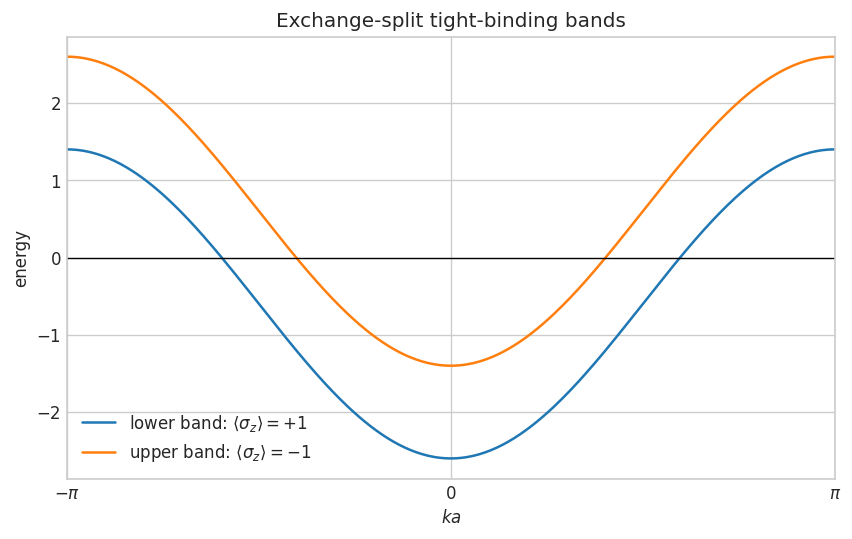

In [6]:
k_plot = np.linspace(-np.pi, np.pi, 401)
t_hop = 1.0
delta_exchange = 1.2

bands_exchange = np.array(
    [np.linalg.eigvalsh(bloch_hamiltonian(k, t_hop, delta_exchange, 0.0)) for k in k_plot]
)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(k_plot, bands_exchange[:, 0], label=r"lower band: $\langle\sigma_z\rangle=+1$")
ax.plot(k_plot, bands_exchange[:, 1], label=r"upper band: $\langle\sigma_z\rangle=-1$")
ax.axhline(0, color="black", lw=0.8)
ax.set(
    xlabel=r"$ka$",
    ylabel="energy",
    title="Exchange-split tight-binding bands",
    xlim=(-np.pi, np.pi),
)
ax.set_xticks([-np.pi, 0, np.pi], [r"$-\pi$", "0", r"$\pi$"])
ax.legend()
plt.tight_layout()
plt.show()

## 8. Constructing a Bloch state explicitly

For band $n$ and momentum $k$, let $|u_n(k)\rangle\in\mathbb C^2$ be an eigenvector of $H(k)$. The full state on the finite ring is

$$
|\Psi_{nk}\rangle
=
\frac{1}{\sqrt N}
\sum_{j=0}^{N-1}e^{ikja}|j\rangle\otimes|u_n(k)\rangle.
$$

The factor $e^{ikja}$ carries the lattice phase. The spinor $|u_n(k)\rangle$ carries the internal spin state. In a one-orbital unit cell, the periodic part has only this spin structure; multi-orbital crystals produce a larger $k$-dependent periodic vector.

Translation eigenvalue: (0.38268343236508984-0.9238795325112867j)
Translation-eigenstate residual: 5.796930155373255e-16
Internal spin Bloch vector: [ 0.     -0.7331  0.6801]


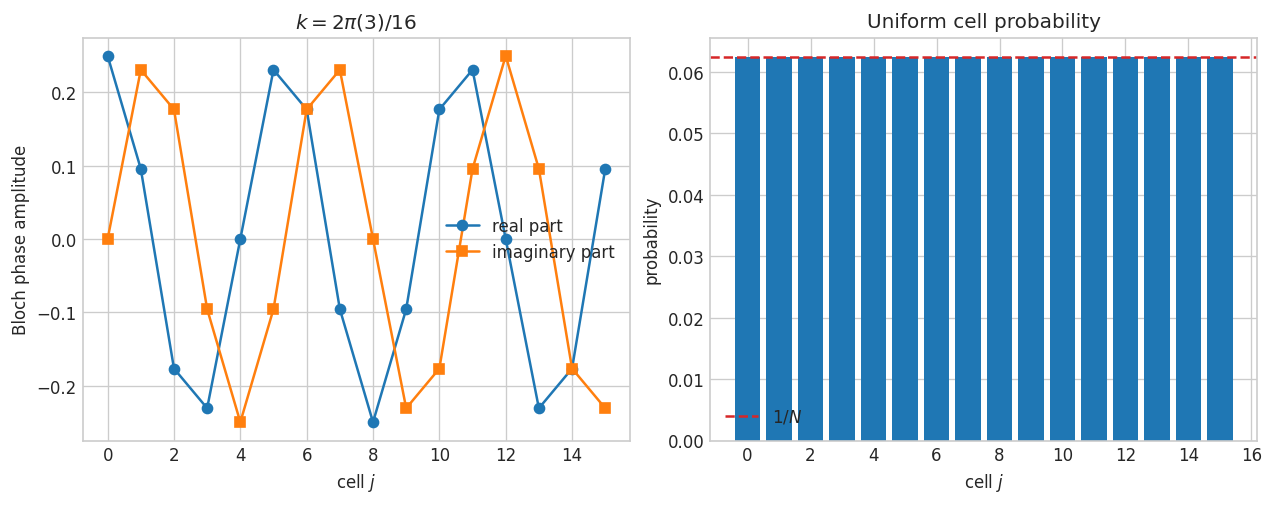

In [7]:
def full_bloch_state(n_cells, k, internal_spinor):
    internal_spinor = normalize(internal_spinor)
    phase = np.exp(1j * k * np.arange(n_cells)) / np.sqrt(n_cells)
    return np.kron(phase, internal_spinor)


n_cells = 16
k_index = 3
k_selected = 2 * np.pi * k_index / n_cells
H_k = bloch_hamiltonian(k_selected, t_hop=1.0, delta=1.2, spin_orbit=0.35)
_, u_k = np.linalg.eigh(H_k)
psi_bloch = full_bloch_state(n_cells, k_selected, u_k[:, 0])
T_ring = translation_operator(n_cells)
translation_eigenvalue = np.exp(-1j * k_selected)
translation_residual = np.linalg.norm(T_ring @ psi_bloch - translation_eigenvalue * psi_bloch)

cell_amplitudes = psi_bloch.reshape(n_cells, 2)
cell_probability = np.sum(np.abs(cell_amplitudes) ** 2, axis=1)
phase_factor = np.exp(1j * k_selected * np.arange(n_cells)) / np.sqrt(n_cells)

assert np.isclose(np.linalg.norm(psi_bloch), 1.0)
assert np.allclose(cell_probability, 1.0 / n_cells)
assert translation_residual < 1e-12

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.1), constrained_layout=True)
axes[0].plot(np.arange(n_cells), phase_factor.real, "o-", label="real part")
axes[0].plot(np.arange(n_cells), phase_factor.imag, "s-", label="imaginary part")
axes[0].set(xlabel="cell $j$", ylabel="Bloch phase amplitude", title=rf"$k=2\pi({k_index})/{n_cells}$")
axes[0].legend()

axes[1].bar(np.arange(n_cells), cell_probability)
axes[1].axhline(1 / n_cells, color="tab:red", ls="--", label=r"$1/N$")
axes[1].set(xlabel="cell $j$", ylabel="probability", title="Uniform cell probability")
axes[1].legend()
plt.show()

print("Translation eigenvalue:", translation_eigenvalue)
print("Translation-eigenstate residual:", translation_residual)
print("Internal spin Bloch vector:", bloch_vector(u_k[:, 0]))

## 9. Momentum-dependent spin texture

With $\lambda\ne0$,

$$
H(k)=\varepsilon_0(k)I+\mathbf d(k)\cdot\boldsymbol\sigma,
$$

where

$$
\varepsilon_0(k)=-2\tau\cos(ka),
\qquad
\mathbf d(k)=
\left(0,2\lambda\sin(ka),-\frac{\Delta}{2}\right).
$$

The eigenenergies are

$$
E_\pm(k)=\varepsilon_0(k)\pm|\mathbf d(k)|.
$$

The internal spinor now depends on $k$. Spin is no longer an independent up/down label along $z$; it becomes a momentum-dependent expectation value. This is a minimal spin-texture model, not a quantitative Hamiltonian for a specific material.

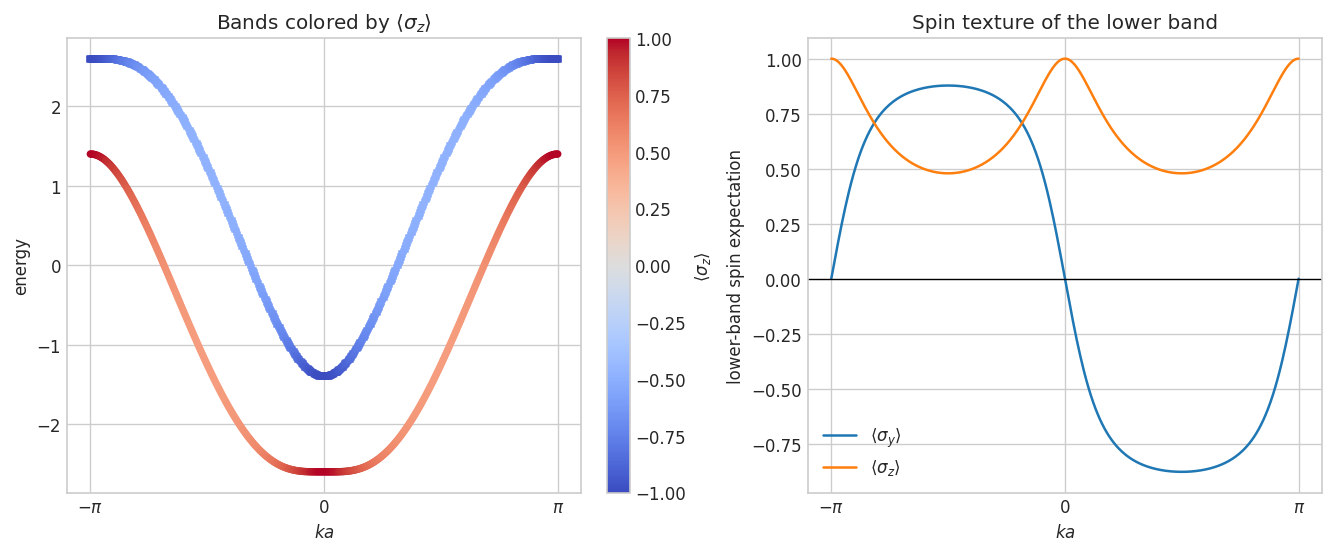

In [8]:
spin_orbit = 0.55
delta_texture = 1.2
energies_texture = np.zeros((len(k_plot), 2))
spin_texture = np.zeros((len(k_plot), 2, 3))

for k_index, k in enumerate(k_plot):
    eigenvalues, eigenvectors = np.linalg.eigh(
        bloch_hamiltonian(k, t_hop=t_hop, delta=delta_texture, spin_orbit=spin_orbit)
    )
    energies_texture[k_index] = eigenvalues
    for band in range(2):
        spin_texture[k_index, band] = bloch_vector(eigenvectors[:, band])

assert np.allclose(np.linalg.norm(spin_texture, axis=2), 1.0)
assert np.allclose(spin_texture[:, :, 0], 0.0, atol=1e-12)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for band, marker in zip(range(2), ("o", "s")):
    points = axes[0].scatter(
        k_plot,
        energies_texture[:, band],
        c=spin_texture[:, band, 2],
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        s=12,
        marker=marker,
    )
axes[0].set(xlabel=r"$ka$", ylabel="energy", title=r"Bands colored by $\langle\sigma_z\rangle$")
axes[0].set_xticks([-np.pi, 0, np.pi], [r"$-\pi$", "0", r"$\pi$"])
plt.colorbar(points, ax=axes[0], label=r"$\langle\sigma_z\rangle$")

axes[1].plot(k_plot, spin_texture[:, 0, 1], label=r"$\langle\sigma_y\rangle$")
axes[1].plot(k_plot, spin_texture[:, 0, 2], label=r"$\langle\sigma_z\rangle$")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set(xlabel=r"$ka$", ylabel="lower-band spin expectation", title="Spin texture of the lower band")
axes[1].set_xticks([-np.pi, 0, np.pi], [r"$-\pi$", "0", r"$\pi$"])
axes[1].legend()
plt.show()

## 10. Occupation and band spin polarization

Bloch eigenstates alone do not determine a bulk magnetic response. We must also specify which states are occupied. For chemical potential $\mu$ and occupation temperature $T_{\mathrm{occ}}$,

$$
f(E;\mu,T_{\mathrm{occ}})
=\frac{1}{e^{(E-\mu)/T_{\mathrm{occ}}}+1}.
$$

The electron density per cell and dimensionless $z$-spin polarization per cell are approximated by

$$
n_e
=\frac{1}{N_k}\sum_{n,k}f(E_{nk}),
\qquad
p_z
=\frac{1}{N_k}\sum_{n,k}f(E_{nk})
\langle u_n(k)|\sigma_z|u_n(k)\rangle.
$$

The physical spin angular momentum is $(\hbar/2)p_z$ per cell. For electrons, the corresponding magnetic moment has the opposite sign. The parameter $\Delta$ remains imposed; a Stoner or mean-field model would determine it self-consistently from the occupied states.

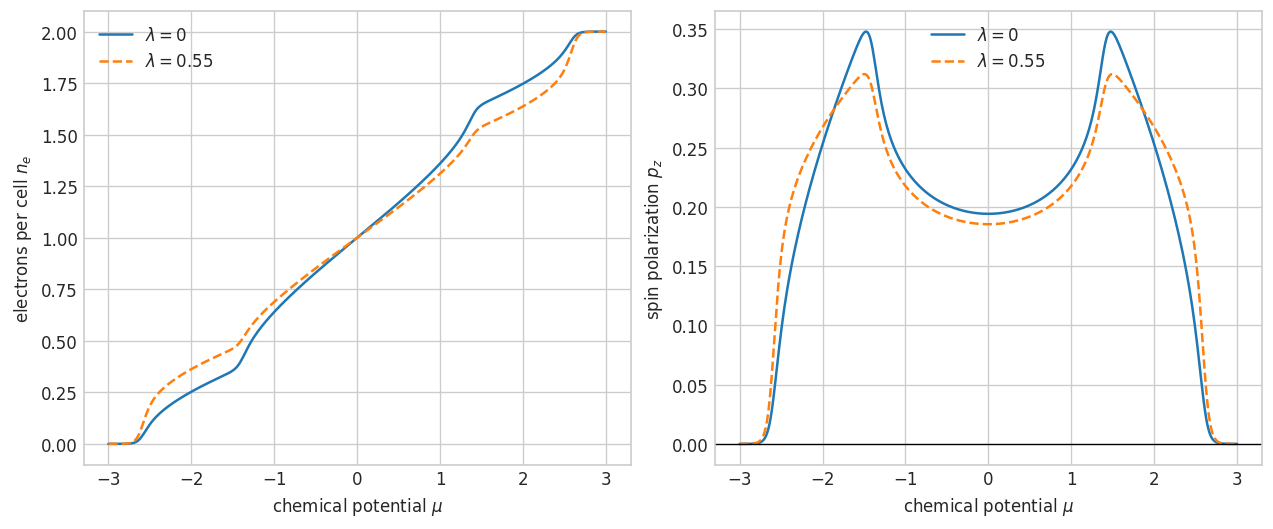

In [9]:
def band_data(k_values, t_hop, delta, spin_orbit):
    energies = np.zeros((len(k_values), 2))
    spin_z = np.zeros_like(energies)
    for k_index, k in enumerate(k_values):
        eigenvalues, eigenvectors = np.linalg.eigh(
            bloch_hamiltonian(k, t_hop, delta, spin_orbit)
        )
        energies[k_index] = eigenvalues
        spin_z[k_index] = [bloch_vector(eigenvectors[:, band])[2] for band in range(2)]
    return energies, spin_z


def fermi_function(energies, chemical_potential, temperature):
    argument = np.clip((energies - chemical_potential) / temperature, -700, 700)
    return 1.0 / (np.exp(argument) + 1.0)


def filling_curve(k_values, chemical_potentials, t_hop, delta, spin_orbit, temperature=0.04):
    energies, spin_z = band_data(k_values, t_hop, delta, spin_orbit)
    density = []
    polarization_z = []
    for mu in chemical_potentials:
        occupation = fermi_function(energies, mu, temperature)
        density.append(np.sum(occupation) / len(k_values))
        polarization_z.append(np.sum(occupation * spin_z) / len(k_values))
    return np.array(density), np.array(polarization_z)


k_dense = np.linspace(-np.pi, np.pi, 801, endpoint=False)
chemical_potentials = np.linspace(-3.0, 3.0, 401)

n_no_soc, p_no_soc = filling_curve(
    k_dense, chemical_potentials, t_hop=1.0, delta=1.2, spin_orbit=0.0
)
n_soc, p_soc = filling_curve(
    k_dense, chemical_potentials, t_hop=1.0, delta=1.2, spin_orbit=0.55
)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3), constrained_layout=True)
axes[0].plot(chemical_potentials, n_no_soc, label=r"$\lambda=0$")
axes[0].plot(chemical_potentials, n_soc, "--", label=r"$\lambda=0.55$")
axes[0].set(xlabel=r"chemical potential $\mu$", ylabel=r"electrons per cell $n_e$")
axes[0].legend()

axes[1].plot(chemical_potentials, p_no_soc, label=r"$\lambda=0$")
axes[1].plot(chemical_potentials, p_soc, "--", label=r"$\lambda=0.55$")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set(xlabel=r"chemical potential $\mu$", ylabel=r"spin polarization $p_z$")
axes[1].legend()
plt.show()

## 11. Model hierarchy and interpretation

| Level | State | Hamiltonian | What is represented |
| --- | --- | --- | --- |
| Single spin | $|\psi\rangle\in\mathbb C^2$ | $H_Z=-(\Delta/2)\mathbf n\cdot\boldsymbol\sigma$ | Local two-level spin dynamics |
| Finite ring | $|\Psi\rangle\in\mathbb C^N\otimes\mathbb C^2$ | $2N\times2N$ real-space matrix | Cells, periodic boundaries, hopping, spin |
| Bloch fiber | $|u_n(k)\rangle\in\mathbb C^2$ | $H(k)$ | Band energy and internal spin at fixed $k$ |
| Occupied bands | $f_{nk}$ plus $|u_n(k)\rangle$ | Same one-particle model | Density and net spin polarization |

The model is intentionally reduced. It omits orbital magnetism, dipole-dipole coupling, many-body entanglement, self-consistent exchange, disorder, phonons, and a material-specific orbital basis. Its publishable or predictive content would therefore require a justified mapping from a reference electronic-structure model to the parameters $\tau$, $\Delta$, and $\lambda$.

## 12. Exercises

### Exercise 1 — Spin measurement

For $|\psi\rangle=|+x\rangle$, compute the probabilities of measuring $S_z=\pm\tfrac12$ analytically and numerically. Repeat for measurement along an arbitrary unit vector $\mathbf n$.

### Exercise 2 — Arbitrary-field precession

Choose $\mathbf n_B=(1,1,1)/\sqrt3$. Evolve a state not parallel to $\mathbf n_B$. Verify numerically that

$$
\mathbf n_B\cdot\langle\boldsymbol\sigma\rangle
$$

is conserved and that the perpendicular component rotates.

### Exercise 3 — Translation convention

Change the Bloch phase convention to $e^{-ikja}$. Re-derive the translation eigenvalue and $H(k)$. Identify which signs change and show that the band energies do not.

### Exercise 4 — Open boundaries

Replace the ring by an open chain. Compute $[H,T_a]$ and explain why crystal momentum is no longer an exact quantum number. Compare the open-chain spectrum with the periodic spectrum as $N$ increases.

### Exercise 5 — Time-reversal symmetry

Set $\Delta=0$ while retaining $\lambda\ne0$. Verify

$$
E_n(k)=E_n(-k)
$$

and compare the spin expectation values at $k$ and $-k$. Then restore $\Delta$ and identify which relations fail.

### Exercise 6 — Self-consistent exchange

Replace the imposed splitting by a mean-field condition such as

$$
\Delta=I p_z,
$$

where $I$ is an interaction parameter. Iterate the occupied-band calculation to self-consistency. Determine when a nonzero solution appears and separate numerical convergence from physical stability.

### Exercise 7 — Two orbitals per cell

Extend the internal fiber from $\mathbb C^2$ to $\mathbb C^2_{\mathrm{orbital}}\otimes\mathbb C^2_{\mathrm{spin}}$. Construct a $4\times4$ Bloch Hamiltonian and distinguish orbital pseudospin from real spin.

## 13. Summary

The two models form a controlled sequence:

$$
\boxed{
\text{single spin in }\mathbb C^2
\longrightarrow
\text{spin at every lattice cell}
\longrightarrow
\text{$k$-resolved spinful Bloch Hamiltonian}
\longrightarrow
\text{occupied-band spin polarization}.
}
$$

The single-spin model establishes operators, measurement, and unitary dynamics. Translation symmetry then decomposes the lattice Hamiltonian into small $k$-resolved matrices. Each Bloch eigenstate contains both a lattice phase and an internal spinor. Magnetism at the band level finally depends on the spin character **and** occupation of those eigenstates.

## References

1. J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*.
2. D. J. Griffiths and D. F. Schroeter, *Introduction to Quantum Mechanics*.
3. N. W. Ashcroft and N. D. Mermin, *Solid State Physics*.
4. R. M. Martin, *Electronic Structure: Basic Theory and Practical Methods*.
5. S. Blundell, *Magnetism in Condensed Matter*.